In [3]:
import housing
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

# 1. Creazione di Dati Sintetici
np.random.seed(42)
X = np.random.rand(100, 10) # 10 predittori (alcuni irrilevanti)
# Y è principalmente basato su X[:,0] e X[:,1]
y = 5*X[:,0] - 2 * X[:,1] + 0.1 * X[:,9] + np.random.randn(100) * 0.5
# 2. Standardizzazione dei Dati (Cruciale per la regolarizzazione)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
# Definiamo il parametro di tuning lambda (alpha in scikit-learn)
alpha_value = 1.0
# 3. Fitting dei Modelli.
# a) OLS (Non regolarizzata)
ols_model = LinearRegression().fit(X_train, y_train)
# b) Ridge Regression (Penalità L2)
ridge_model = Ridge(alpha=alpha_value).fit(X_train, y_train)
# c) Lasso Regression (Penalità L1)
lasso_model = Lasso(alpha=alpha_value).fit(X_train, y_train)
# 4. Confronto dei coefficienti
print(f"--- Confronto Coefficienti (Alpha = {alpha_value}) ---\n")
coef_df = pd.DataFrame({
    'OLS': ols_model.coef_.round(2),
    'Ridge (L2)': ridge_model.coef_.round(2),
    'Lasso (L1)' : lasso_model.coef_.round(2),
}, index=[f'X{i}' for i in range(10)])
print(coef_df)

ModuleNotFoundError: No module named 'housing'

Esempio Heat Map con dataset california housing

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Caricamento dataset di esempio
data = fetch_california_housing()
X, y = data.data, data.target

# Suddivisione in train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creazione del modello Elastic Net
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)

# Addestramento
elastic_net.fit(X_train, y_train)

# Predizione
y_pred = elastic_net.predict(X_test)

# Valutazione del modello
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE): ", mse)

# Coefficienti del modello
print("Coefficenti:", elastic_net.coef_)


Analizzazione dei risultati dell'algoritmo

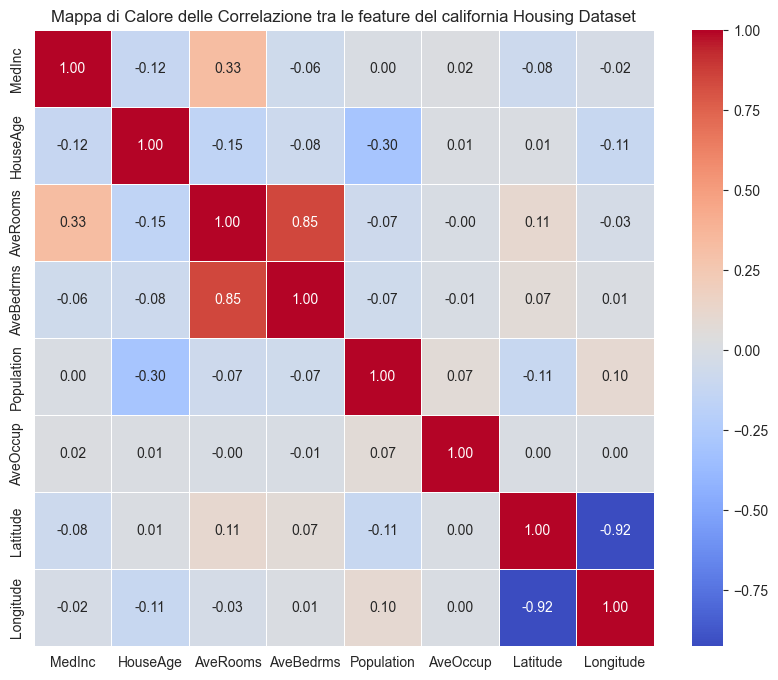

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Converti le feature in un DataFrame Pandas per facilitare l'analisi
df_features = pd.DataFrame(data.data, columns=data.feature_names)

correlation_matrix = df_features.corr()

# Crea la mappa di calore
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=.5)
plt.title('Mappa di Calore delle Correlazione tra le feature del california Housing Dataset')
plt.show()